In [ ]:
######## THIS CODE GIVES A MODEL FOR INFECTION AND THEN YOU CAN ADJUST THE COEFFICENTS USING LOCAL, TINE-DEPENDENT AND NN-AUGMENTED APPROACHES ########
########## PLEASE RUN THE CELLS IN ORDER ##############################################
######### Using this code you can regenerate Figure 9, 10 and 11 and Table 5 #################################

####### Importing the required packages #######
using DataFrames
using CSV
using Plots
using ModelingToolkit, OrdinaryDiffEq, LinearAlgebra
using DifferentialEquations
using DataDrivenDiffEq
using DataDrivenSparse
using StatsPlots
using Statistics
using Distributions
using Dates
using DSP
using RecursiveArrayTools
using DiffEqParamEstim
using Optimization, OptimizationOptimJL
using OptimizationBBO, Optim
using ForwardDiff
using PenaltyFunctions
using Turing
using StableRNGs
using DataInterpolations
using ComponentArrays
using StatsBase
using Random
using Lux, SciMLSensitivity
using OptimizationOptimisers

In [43]:
#################### Making the Data #######################################
theme(:bright)
rng = StableRNG(20)

start_training=350
finish_training=680
##### specify the range you want to chop out for prediction
split_start= 635 
split_finish=split_start+28

begin
    raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
    data=Matrix(raw_data[:,[2, 3]])'
      
    s=size(data)[2]
    for i in 1:s
        data[1,i]=mean(data[1,max(1,i-5):min(s,i)])
    end
    ############# Beta distribution

    function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
        d=Beta(α, β)
        max=pdf(d, mode(d))
        step=1/(n+2-1)
        steps=collect(0.0:step: 1.0)
        coefs=zeros(length(steps))
        for i in eachindex(coefs)
            coefs[i]=pdf(d,steps[i])/max
        end
        return steps[2:end-1], coefs[2:end-1]
    end

    n=21  #### number of days that infection rate of each patient changes
    vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

    ###############################  factors should be  used ######################

    infectiveness=zeros(size(data)[2],1);
    infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
   
    #smoothing the infectiveness
    for i in eachindex(infectiveness)
        infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
    end

  
    data1=copy(data)
    data1[2,:]=infectiveness
    
    Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
    Min=0
    for i in 1:size(data1)[1]
        for j in 1:size(data1)[2]
            data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
        end
    end 
    
    data2=data1[:,start_training:split_start]
    data3=data1[:,split_finish:finish_training]
    
    X1=copy(data2);
    X2=copy(data3);
end

2×18 Matrix{Float64}:
 0.831353  0.810928  0.791322  0.773526  …  0.566087  0.5488    0.530753
 0.998599  1.0       0.999803  0.998053     0.888634  0.874853  0.860613

In [44]:
############################# Making control signal ########################
begin
    v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
    v_data=Matrix{Float64}(v_raw_data[:,3:5])'

   
    ####  weekly averaging
     avg_days=7
    s=size(v_data)
    weekly=Matrix{Float64}(undef,s[1], s[2])
    for i in 1:size(v_data)[1]
        weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
    end
    #avg_days=7
   
    ############# beta distribution  

    n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
    vvals, vcofs=factors(3,4,n) #### α=4 and β=4, we can change the curve shape by changing α and β


    ###############################  factors should be reversed and used ######################
    dose1=zeros(size(v_data)[2],1);
    dose2=zeros(size(v_data)[2],1);
    dose3=zeros(size(v_data)[2],1);

    vcofs1=reverse(reverse(vcofs))
    for i in 1:lastindex(dose1)
        for j in 1:min(n,i)-1
            dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
            dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
            dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
        end 
    end

    dose11=zeros(size(raw_data)[1],1);
    dose21=zeros(size(raw_data)[1],1);
    dose31=zeros(size(raw_data)[1],1);

    difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
    
    for i in difference+1:lastindex(dose11)
        dose11[i]=dose1[i-difference]
        dose21[i]=dose2[i-difference]
        dose31[i]=dose3[i-difference]
    end

    antibody=dose11.+dose21.+ dose31
    
    Max_antibody=maximum(antibody)
    Min=0#minimum(v_data)
    for i in 1:size(antibody)[1]       
        antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
    end
    
    control=vcat(antibody'); 
    control1=vcat(antibody[start_training:split_start]');
    control2=vcat(antibody[split_finish:finish_training]');

end

1×18 Matrix{Float64}:
 0.951872  0.968372  0.98194  0.991967  …  0.78242  0.749704  0.718941

In [51]:
######################## definition and solving of the problem ##################
begin
    tick=100_000
    t1=collect(0.0:1/tick:(split_start-start_training)/tick);
    itp_method=InterpolationMethod(LinearInterpolation)

    sir_problem1=ContinuousDataDrivenProblem(X1, t1, itp_method, U = control1)

    t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
    
    final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
    sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

    @variables u[1:2] c[1:1]
    u = collect(u)
    c = collect(c)

    if start_training==1
        h = Num[polynomial_basis([u; c], 1);]# exp(c[1]);exp(c[2]);exp(c[3]);]
    else
        h = Num[polynomial_basis([u; c], 2);]
    end

    basis = Basis(h, u, controls=c)
    

    ### choosing STLSQ as an optimizer
    ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
    opt = STLSQ(exp10.(-3:0.01:+5))


    #sampler = DataProcessing(split = 0.7, shuffle=true, batchsize = 30, rng = rng)

    options = DataDrivenCommonOptions(maxiters = 1000, 
                                  normalize = DataNormalization(ZScoreTransform),
                                  selector = bic, digits = 3)

    ddsol = solve(sir_problem, basis, opt, options=options);
   
end

"DataDrivenSolution{Float64}"

In [49]:
################## recovering the dynamic  ########################
window=6
begin
    ##### range of prediction ####
    newdays=window
    start=split_start+newdays
    finish=split_finish
    
    
    res=ddsol
    sys = get_basis(res)
    

    # Optimal parameters
    p_opt = get_parameter_values(sys)
    
    z0=data1[:,start]

    ztspan=(start/tick,finish/tick)

    u=control
    tsteps = range(0.0, 706/tick, length = 707)
    A=LinearInterpolation(u,tsteps);


    function get_dose1(t)
        return A(t)[1]
    end

    function get_total_antibody(t)
        down=control[1, Int(round(t*tick+1, RoundDown))]
        up=control[1, Int(round(t*tick+1, RoundUp))]
        down_co=t*tick-round(t*tick,RoundDown)
        up_co=1-down_co
        control_in_t=down_co*down+up_co*up
        return control_in_t
    end

    # Generate a closure on the system 
    f_recovered = let doese_1 = get_dose1
       (x, p, t) -> sys(x, p, t, [doese_1.(t)])
    end
    f_recovered1 = let doese_1 = get_total_antibody
        (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
    end    
end

#126 (generic function with 1 method)

In [50]:
#################### Making projection using Global Coefficients #########################
ptest=plot(data1[1,start-window:finish]*Max_data1[1], label="Data", lw=4, color=:black, ls=:dash, title="Daily Prediction Using Different Coefficients",  legend=:topleft,
             yminorticks=2, xminorticks = 7, xticks=1:7:finish-start+1)
p_opt = get_parameter_values(sys)
begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=1.0
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);

    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)
      
        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)       
        y2[:,i]=M[2,:]
        
    end
    
    ptest=errorline!(1+window:finish-start+1+window, y1[:,:]*Max_data1[1], errorstyle=:plume, label="Global Coefficients",
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    
    
end

┌ Warning: Instability detected. Aborting
└ @ SciMLBase C:\Users\babazadehmorteza\.julia\packages\SciMLBase\rvXrA\src\integrator_interface.jl:631


DimensionMismatch: DimensionMismatch: tried to assign 19-element array to 23×1 destination

In [7]:
########### Local Coefficients Adjustment using 7 days of previous data points  #############
begin
    p1=get_parameter_values(sys);
    p=zeros(size(p1));
    prms=[];
    push!(prms, p1);
    window=6;
   
    new_data=data1[:,split_start:split_start+window];
    u0=data1[:,split_start];
   
    tspan=((split_start)/tick, (split_start+window)/tick);
    t=collect((split_start)/tick:1/tick:(split_start+window)/tick);
   
    problem=ODEProblem(f_recovered1, u0, tspan, p);


    ########## Objective Function for Optim.jl ##################
    cost_function=build_loss_objective(problem, Tsit5(), DiffEqParamEstim.L2Loss(t, new_data), 
                                        Optimization.AutoForwardDiff(),  Regularization(sum(abs.(p_opt))exp10(-30), L2Penalty()),
                                        maxiters=1000, verbose=false);

    ###### Optimization of the Parameter ###############################################
    optprob=Optimization.OptimizationProblem(cost_function, p);
    optsol=solve(optprob, BFGS());
    push!(prms, optsol.u.+ p1);

    params2=reduce(hcat, prms);

end

19×2 Matrix{Float64}:
   257.665    165.822
  7861.2     7780.89
  5124.79    5054.42
 -6502.5    -6554.5
 -9354.61   -9400.2
  4306.4     4276.86
  -980.786  -1021.13
 -4918.8    -4954.35
  2046.45    2023.34
   921.336    903.263
   -90.183    -73.8972
  6170.24    6184.11
 -3623.79   -3611.97
 -5871.18   -5862.28
  7807.15    7814.74
 -3857.72   -3852.85
   374.969    381.209
   971.185    974.573
  -417.704   -415.363

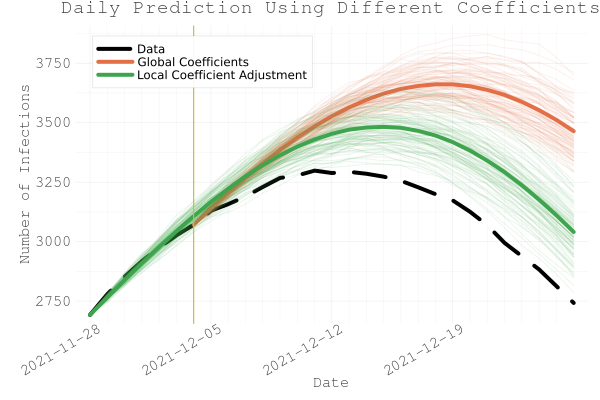

In [8]:
#################### making projection using the Locally adjusted Coefficients #########################
start = split_start
z0=data1[:,start]
ztspan=(start/tick,finish/tick)


dates=raw_data[start:finish+1,1];
p_opt2=params2[:,2]#optimised parameters
begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=1.0
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);
  
    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt2)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)

        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)

        y2[:,i]=M[2,:]

    end

    ptest=errorline!(1:finish-start+1, y1[:,:]*Max_data1[1], errorstyle=:plume, label="Local Coefficient Adjustment", 
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))

end
plot!(ptest,xformatter= x->Dates.format(dates[Int(round(x+1, RoundDown))], "yyyy-mm-dd"), xrot=30, xlabel="Date")
plot!([window+1], seriestype=vline, label=false)

In [9]:
############################################ Time-dependent Coefficient Adjustment #######################################

p1=get_parameter_values(sys);
true_params = p1

p=zeros(size(p1));
all_prms=[]

prms=[];
[push!(prms, p1) for _ in 1:10]
window=6;
for step in 1:finish_training-start_training-window-1 #-180:20#
    new_data=data1[:,start_training+step:start_training+window+step]

    u0=new_data[:,1]
    tspan=((start_training+step)/tick, (start_training+window+step)/tick)
    t=collect((start_training+step)/tick:1/tick:(start_training+window+step)/tick)

    # Define the objective function for optimization
    function objective_function(params, data, alpha)
        y_observed = data
        prob = ODEProblem(f_recovered, u0, tspan, params)
        sol = solve(prob, saveat=1/tick)
        y_predicted = sol(t)
        error = y_observed .- y_predicted
        tmp_prms=copy(prms)
        push!(tmp_prms, params)
        tmp_prms=reduce(hcat, tmp_prms)
        tv_penalty=0
        for k in 1:length(params)
            tv_penalty+=sum(diff(tmp_prms[k,:]))
        end

        return sum(error.^2) + alpha * tv_penalty  # alpha is the regularization strength
    end
    

    
    true_params = p1
    data =new_data

    # Initial guess for ODE parameters
    initial_guess = p1 

    # Regularization strength
    alpha =sum(abs.(p_opt))exp10(-30)

    
    options = Optim.Options(iterations=100)
    result = Optim.optimize(params -> objective_function(params, data, alpha), initial_guess, LBFGS(), options)

    # Extract the optimized parameters
    optimized_params = Optim.minimizer(result)
    push!(all_prms, optimized_params)
    p1=optimized_params
    push!(prms, optimized_params)
    popfirst!(prms)

end
finial_prms=reduce(hcat, all_prms);

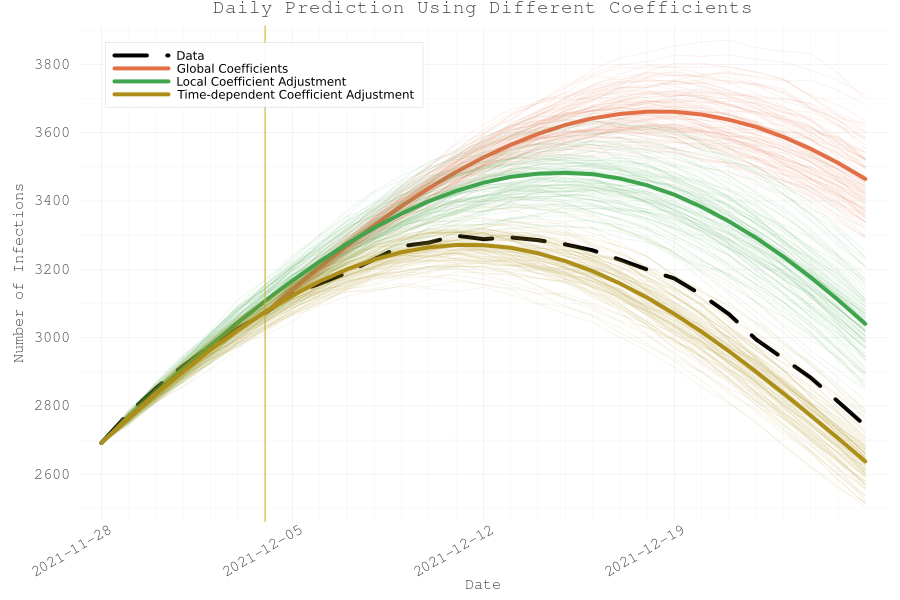

In [10]:
#################### Making projection using the Time-dependently adjusted coefficients #########################
p_opt2=finial_prms[:,split_start-start_training+1]#

begin
    theme(:bright)
    raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
    data_end=Matrix(raw_data_end[:,[2, 3]])'
    t_step=1/tick
    beta=1
    
    g(u,p,t)=beta*u   #### stochastic function and its parameters

    ################## StatsPlots ################
    y1 = fill(NaN, finish-start+1, 1000);
    y2 = fill(NaN, finish-start+1, 1000);

    for i  in 1:1000
        prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt2)
        prediction = solve(prediction_prob, EM(), dt=t_step)
        M=Matrix(prediction)

       
        y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)
              
        y2[:,i]=M[2,:]
        
    end
    
    ptest=errorline!(1:finish-start+1, y1[:,:]*Max_data1[1], errorstyle=:plume, label="Time-dependent Coefficient Adjustment", size=(900,600),
                     lw=4, left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, ylabel="Number of Infections",
                     titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
                     ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"))
    
end

In [11]:
############################# Neural Augmented ODE adjustment using Universal Differential Equations ###############
begin  
    
    rbf(x) = exp.(-(x .^ 2))

    # Multilayer FeedForward
    U = Lux.Chain(Lux.Dense(2, 5, rbf), Lux.Dense(5, 5, rbf), Lux.Dense(5, 5, rbf),
                Lux.Dense(5, 2))

    # Get the initial parameters and state variables of the model
    rng = StableRNG(20)
    p, st = Lux.setup(rng, U)
    ###
    function ude_dynamics!(du, u, p, t, p_true)

        û = U(u, p, st)[1] # Network prediction
        tmp=f_recovered(u, p_true, t)

        du[1] = tmp[1] + û[1];
        du[2] = tmp[2] + û[2];

    end

    # Closure with the known parameter
    nn_dynamics!(du, u, p, t) = ude_dynamics!(du, u, p, t, p_opt)
    # Define the problem
    prob_nn = ODEProblem(nn_dynamics!, z0, ztspan, p)

    ### ### ###
    start=split_start
    finish=split_start+6
    t=collect(start/tick:1/tick:finish/tick)
    z0=data1[:,start]

    using ComponentArrays

    function pred(θ, X = z0, T = t)
        _prob = remake(prob_nn, u0 = X, tspan = (T[1], T[end]), p = θ)
        Array(solve(_prob, Tsit5(), saveat = T,
                    abstol = 1e-6, reltol = 1e-6))
    end
    function loss(θ)
        X̂ = pred(θ)
        
        mean(abs2, data1[:,start:finish] .- X̂)
    end
    losses = Float64[]

    callback = function (p, l)
        
        push!(losses, l)
        if length(losses) % 1 == 1000
            println("Current loss after $(length(losses)) iterations: $(losses[end])")
        end
        return false
    end
    adtype = Optimization.AutoForwardDiff()

    optf = Optimization.OptimizationFunction((x, p) -> loss(x), adtype)
    optprob = Optimization.OptimizationProblem(optf, ComponentVector{Float64}(p))

    ### first round of training uisng ADAM ###
    itr=1000
    using SciMLSensitivity
    using Optimization, OptimizationOptimisers, OptimizationOptimJL
    res1 = Optimization.solve(optprob, ADAM(0.001), callback = callback, maxiters = itr)

    ### second round of training using LBFGS ###
    optprob2 = Optimization.OptimizationProblem(optf, res1.u)
    res2 = Optimization.solve(optprob2, Optim.LBFGS(), callback = callback, maxiters = 1000)

    # Rename the best candidate
    p_trained = res2.u;
end

ComponentVector{Float64}(layer_1 = (weight = [-0.7412028863401882 12.063289602379962; -2.451037255988276 -0.610793423803194; … ; 18.153284090186588 28.906119828241913; 1.918985390060276 2.766163589664914], bias = [-13.426575635402349, -2.433175901631554, 1.8884415627057483, -29.94656827428095, 1.158751733865764]), layer_2 = (weight = [-5.386537025639408 -0.14068662499082954 … -4.250021868694212 -3.7013952341054863; 10.182955406567245 2.2014312443160993 … 27.321596650315726 1.1417291059200874; … ; 21.56618914519356 -0.6592173608960236 … -9.872125111940727 -0.9223275878655471; 0.32510225415904653 1.12260395904883 … 0.9738953169090013 2.4992539509993867], bias = [-16.46139170598937, -0.0010266079118641037, 20.8144013136844, 72.27585178422564, 4.519009955386621]), layer_3 = (weight = [1.6302157384317857 1.2000680151544194 … 3.9769938330417163 0.21435428121767913; 1.1183331127866152 -19.78000211077045 … 11.050179747612592 -0.4406250591674135; … ; 1.7579711893268324 2.6039213369736993 … 2.43

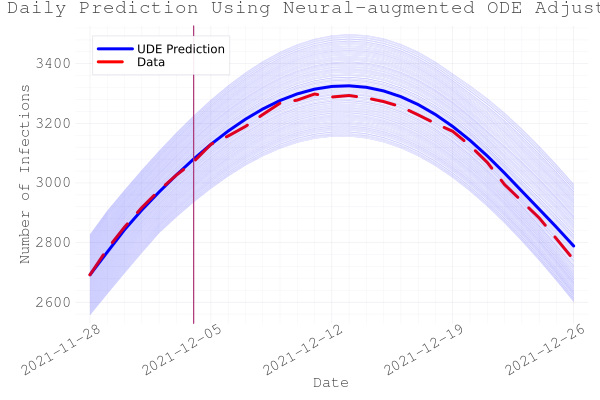

In [12]:
###### making projection after Neural Augmented ODE adjustment ################
##### Figure 10 ####

t1=collect((split_start)/tick:1/tick:(split_finish)/tick)
x1=data1[:, split_start]
plot(pred(p_trained, x1, t1)[1,:]*Max_data1[1], lw=3, label="UDE Prediction", color=:blue)
plot!(data1[1, split_start:split_finish]*Max_data1[1], ls=:dash, lw=3, label="Data", color=:red, alpha=1)

for i in -0.05:0.001:+0.05
    x2=x1+x1.*i
    plot!(pred(p_trained, x2, t1)[1,:]*Max_data1[1], lw=0.5, alpha=0.2, label=false, color=:blue)    
end

plot!(left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, xlabel="Days", ylabel="Number of Infections",
        titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
        ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"), title="Daily Prediction Using Neural-augmented ODE Adjustment")
plot!(xformatter= x->Dates.format(dates[Int(round(x+1, RoundDown))], "yyyy-mm-dd"), xrot=30, xlabel="Date",
     xminorticks = 7,  xticks=1:7:split_finish-start+1)
    
plot!([window+1], seriestype=vline, label=false)

In [13]:
################################ calculating the average residual of the Global coefficients ######################################

#################### Making the Data #######################################
theme(:bright)#:ggplot2)

start_training=350
finish_training=680

real_cases=[]
residuals=[]
for i=50:2:140
    split_start=500+i
    split_finish=520+i
    begin
        raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
        data=Matrix(raw_data[:,[2, 3]])'

        
        s=size(data)[2]
        for i in 1:s
            data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
        end
        ############# Beta distribution

        function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
            d=Beta(α, β)
            max=pdf(d, mode(d))
            step=1/(n+2-1)
            steps=collect(0.0:step: 1.0)
            coefs=zeros(length(steps))
            for i in eachindex(coefs)
                coefs[i]=pdf(d,steps[i])/max
            end
            return steps[2:end-1], coefs[2:end-1]
        end

        n=21  #### number of days that infection rate of each patient changes
        vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

        ###############################  factors should be  used ######################

        infectiveness=zeros(size(data)[2],1);
        infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
    
        #smoothing the infectiveness
        for i in eachindex(infectiveness)
            infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
        end

    
        data1=copy(data)
        data1[2,:]=infectiveness
        Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
        Min=0#minimum(data)
        for i in 1:size(data1)[1]
            for j in 1:size(data1)[2]
                data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
            end
        end 
        
        data2=data1[:,start_training:split_start]
        data3=data1[:,split_finish:finish_training]

        X1=copy(data2)
        X2=copy(data3)
    end

    ############################# Making control signal ########################
    begin
        v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
        v_data=Matrix{Float64}(v_raw_data[:,3:5])'
    
        ####  weekly averaging
        avg_days=7
        s=size(v_data)
        weekly=Matrix{Float64}(undef,s[1], s[2])
        for i in 1:size(v_data)[1]
            weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
        end

    
        ############# beta distribution  

        n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
        vvals, vcofs=factors(3,4,n) #### α=4 and β=4, we can change the curve shape by changing α and β



        ###############################  factors should be reversed and used ######################
        dose1=zeros(size(v_data)[2],1);
        dose2=zeros(size(v_data)[2],1);
        dose3=zeros(size(v_data)[2],1);

        vcofs1=reverse(reverse(vcofs))
        for i in 1:lastindex(dose1)
            for j in 1:min(n,i)-1
                dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
                dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
                dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
            end 
        end

        dose11=zeros(size(raw_data)[1],1);
        dose21=zeros(size(raw_data)[1],1);
        dose31=zeros(size(raw_data)[1],1);

        difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
        
        for i in difference+1:lastindex(dose11)
            dose11[i]=dose1[i-difference]
            dose21[i]=dose2[i-difference]
            dose31[i]=dose3[i-difference]
        end

        antibody=dose11.+dose21.+ dose31

        Max_antibody=maximum(antibody)
        Min=0
        for i in 1:size(antibody)[1]       
            antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
        end

        control=vcat(antibody') ### used in prediction
        control1=vcat(antibody[start_training:split_start]')
        control2=vcat(antibody[split_finish:finish_training]')

    end

    ######################## definition and solving of the problem ##################
    begin
        tick=100_000

        t1=collect(0.0:1/tick:(split_start-start_training)/tick);
        itp_method=InterpolationMethod(LinearInterpolation)


        t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);

        
        final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
        sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

        @variables u[1:2] c[1:1]
        u = collect(u)
        c = collect(c)

        if start_training==1
            h = Num[polynomial_basis([u; c], 1);]

        else
            h = Num[polynomial_basis([u; c], 2);]

        end

        basis = Basis(h, u, controls=c)


        ### choosing STLSQ as an optimizer
        ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
        opt = STLSQ(exp10.(-1:0.01:+5))

        options = DataDrivenCommonOptions(maxiters = 10_000,
                                    normalize = DataNormalization(ZScoreTransform),
                                    selector = aic, digits = 3)

        ddsol = solve(sir_problem, basis, opt, options=options)
        plot(plot(sir_problem, title="data"),plot(ddsol, title="model"), layout=(1,2))
    
    end

    ################## recovering the dynamic +window ########################
    window=6
    begin
        ##### range of prediction ####
        newdays=window
        start=split_start+newdays
        finish=split_finish
        
        
        res=ddsol
        sys = get_basis(res)
        #println(sys)

        # Optimal parameters
        p_opt = get_parameter_values(sys)
               
        z0=data1[:,start]#X1[:,end]#data1[:,start]

        ztspan=(start/tick,finish/tick)

        u=control
        tsteps = range(0.0, 706/tick, length = 707)
        A=LinearInterpolation(u,tsteps);



        function get_dose1(t)
            return A(t)[1]
        end

        function get_total_antibody(t)
            down=control[1, Int(round(t*tick+1, RoundDown))]
            up=control[1, Int(round(t*tick+1, RoundUp))]
            down_co=t*tick-round(t*tick,RoundDown)
            up_co=1-down_co
            control_in_t=down_co*down+up_co*up
            return control_in_t
        end

        # Generate a closure on the system 
        f_recovered = let doese_1 = get_dose1
        (x, p, t) -> sys(x, p, t, [doese_1.(t)])
        end
        f_recovered1 = let doese_1 = get_total_antibody
            (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
        end
    end

    #################### stochastic #########################
    p_opt = get_parameter_values(sys)
    begin
        theme(:bright)
        raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
        data_end=Matrix(raw_data_end[:,[2, 3]])'
        t_step=1/tick
        beta=1
        
        g(u,p,t)=beta*u   #### stochastic function and its parameters

        ################## StatsPlots ################
        y1 = fill(NaN, finish-start+1, 10);
        y2 = fill(NaN, finish-start+1, 10);
    
        for i  in 1:10
            prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt)
            prediction = solve(prediction_prob, EM(), dt=t_step)
            M=Matrix(prediction)
          
            y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)
            
            y2[:,i]=M[2,:]
            
        end
      
    end
    push!(residuals, (abs.(mean(y1,dims=2).-data1[1,start:finish]) ))
    push!(real_cases, data1[1,start:finish])
end

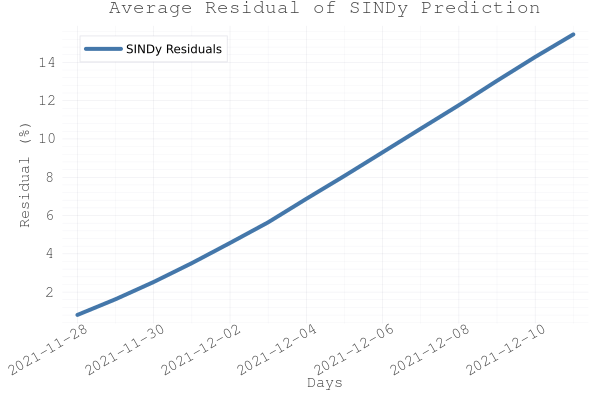

In [14]:
######## Residuals of the Global coefficients ###################
rtemp=mean(reduce(hcat,residuals), dims=2)[2:end]./mean(reduce(hcat,real_cases))*100
plot(mean(reduce(hcat,residuals), dims=2)[2:end]./mean(reduce(hcat,real_cases))*100,  lw=4, label="SINDy Residuals", xticks=1:2:finish-start+1, xminorticks = 2,
    left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, xlabel="Days", ylabel="Residual (%)",
    titlefont=font(10,"Arial"), guidefont = font(8,"Arial"), 
    ytickfont=font(8, "Arial"), xtickfont=font(8, "Arial"), title="Average Residual of SINDy Prediction",
    xformatter= x->Dates.format(dates[Int(round(x+1, RoundDown))], "yyyy-mm-dd"), xrot=30)
#boxplot(reduce(hcat,residuals)'./mean(reduce(hcat,real_cases))'*100,  lw=4, alpha=0.3, label="SINDy Residuals")

In [15]:
################################ calculating the average residual of the Local Coefficient Adjustment ######################################
#################### Making the Data #######################################
theme(:bright)

start_training=350
finish_training=680

residuals1=[]
for i=50:2:140
    split_start=500+i
    split_finish=520+i
    begin
        raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
        data=Matrix(raw_data[:,[2, 3]])'

        
        s=size(data)[2]
        for i in 1:s
            data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
        end
        ############# Beta distribution

        function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
            d=Beta(α, β)
            max=pdf(d, mode(d))
            step=1/(n+2-1)
            steps=collect(0.0:step: 1.0)
            coefs=zeros(length(steps))
            for i in eachindex(coefs)
                coefs[i]=pdf(d,steps[i])/max
            end
            return steps[2:end-1], coefs[2:end-1]
        end

        n=21  #### number of days that infection rate of each patient changes
        vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

    
        ###############################  factors should be  used ######################

        infectiveness=zeros(size(data)[2],1);
        infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
    
        #smoothing the infectiveness
        for i in eachindex(infectiveness)
            infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
        end

    
        data1=copy(data)
        data1[2,:]=infectiveness
        Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
        Min=0#minimum(data)
        for i in 1:size(data1)[1]
            for j in 1:size(data1)[2]
                data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
            end
        end 
        
       
        data2=data1[:,start_training:split_start]
        data3=data1[:,split_finish:finish_training]

        X1=copy(data2)
        X2=copy(data3)
    end

    ############################# Making control signal ########################
    begin
        v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
        v_data=Matrix{Float64}(v_raw_data[:,3:5])'

    
        ####  weekly averaging
        avg_days=7
        s=size(v_data)
        weekly=Matrix{Float64}(undef,s[1], s[2])
        for i in 1:size(v_data)[1]
            weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
        end
    
        ############# beta distribution  

        n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
        vvals, vcofs=factors(3,4,n) #### α=4 and β=4, we can change the curve shape by changing α and β
        #plot(vcofs)


        ###############################  factors should be reversed and used ######################
        dose1=zeros(size(v_data)[2],1);
        dose2=zeros(size(v_data)[2],1);
        dose3=zeros(size(v_data)[2],1);

        vcofs1=reverse(reverse(vcofs))
        for i in 1:lastindex(dose1)
            for j in 1:min(n,i)-1
                dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
                dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
                dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
            end 
        end

        dose11=zeros(size(raw_data)[1],1);
        dose21=zeros(size(raw_data)[1],1);
        dose31=zeros(size(raw_data)[1],1);

        difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
        
        for i in difference+1:lastindex(dose11)
            dose11[i]=dose1[i-difference]
            dose21[i]=dose2[i-difference]
            dose31[i]=dose3[i-difference]
        end


        antibody=dose11.+dose21.+ dose31

        Max_antibody=maximum(antibody)
        Min=0
        for i in 1:size(antibody)[1]       
            antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
        end

        control=vcat(antibody') ### used in prediction
        control1=vcat(antibody[start_training:split_start]')
        control2=vcat(antibody[split_finish:finish_training]')

    end

    ######################## definition and solving of the problem ##################
    begin
        tick=100_000


        t1=collect(0.0:1/tick:(split_start-start_training)/tick);
        itp_method=InterpolationMethod(LinearInterpolation)



        t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);

        
        final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
        sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

        @variables u[1:2] c[1:1]
        u = collect(u)
        c = collect(c)

        if start_training==1
            h = Num[polynomial_basis([u; c], 1);]
        else
            h = Num[polynomial_basis([u; c], 2);]
        end

        basis = Basis(h, u, controls=c)


        ### choosing STLSQ as an optimizer
        ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
        opt = STLSQ(exp10.(-1:0.01:+5))


        options = DataDrivenCommonOptions(maxiters = 10_000,
                                    normalize = DataNormalization(ZScoreTransform),
                                    selector = aic, digits = 3)

        ddsol = solve(sir_problem, basis, opt, options=options)
    
    end

    ################## recovering the dynamic +window ########################
    window=6
    begin
        ##### range of prediction ####
        newdays=window
        start=split_start+newdays
        finish=split_finish
        
        
        res=ddsol
        sys = get_basis(res)
        

        # Optimal parameters
        p_opt = get_parameter_values(sys)
       
        
        z0=data1[:,start]#X1[:,end]#data1[:,start]
        

        ztspan=(start/tick,finish/tick)

        
        u=control
        tsteps = range(0.0, 706/tick, length = 707)
        A=LinearInterpolation(u,tsteps);



        function get_dose1(t)
            return A(t)[1]
        end


        function get_total_antibody(t)
            down=control[1, Int(round(t*tick+1, RoundDown))]
            up=control[1, Int(round(t*tick+1, RoundUp))]
            down_co=t*tick-round(t*tick,RoundDown)
            up_co=1-down_co
            control_in_t=down_co*down+up_co*up
            return control_in_t

        end

        # Generate a closure on the system 
        f_recovered = let doese_1 = get_dose1
        (x, p, t) -> sys(x, p, t, [doese_1.(t)])
        end
        f_recovered1 = let doese_1 = get_total_antibody
            (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
        end
        sys    
    end

    ########### Optmimization of the coeffients WITH REGULARIZATION PENALTY FUNCTION + days  #############
    begin
        p1=get_parameter_values(sys);
        p=zeros(size(p1));
        prms=[];
        push!(prms, p1);
        window=6;
        
        new_data=data1[:,split_start:split_start+window];
        u0=data1[:,split_start];
        
        tspan=((split_start)/tick, (split_start+window)/tick);
        t=collect((split_start)/tick:1/tick:(split_start+window)/tick);
        
        problem=ODEProblem(f_recovered1, u0, tspan, p);


        ########## Objective Function for Optim.jl ##################
      
        cost_function=build_loss_objective(problem, Tsit5(), DiffEqParamEstim.L2Loss(t, new_data), 
                                            Optimization.AutoForwardDiff(),  Regularization(sum(abs.(p_opt))exp10(-30), L2Penalty()),
                                            maxiters=1000, verbose=false);

        ###### Optimization of the Parameter ###############################################
        optprob=Optimization.OptimizationProblem(cost_function, p);
        optsol=solve(optprob, BFGS());
        push!(prms, optsol.u.+ p1);
      
        params2=reduce(hcat, prms);
        
    end


    #################### stochastic #########################
    p_opt2=params2[:,2]
    begin
        theme(:bright)
        raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
        data_end=Matrix(raw_data_end[:,[2, 3]])'
        t_step=1/tick
        beta=1
        
        g(u,p,t)=beta*u   #### stochastic function and its parameters

        ################## StatsPlots ################
        y1 = fill(NaN, finish-start+1, 10);
        y2 = fill(NaN, finish-start+1, 10);
      
        for i  in 1:10
            prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt2)
            prediction = solve(prediction_prob, EM(), dt=t_step)
            M=Matrix(prediction)
      
      
            y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)
      
            y2[:,i]=M[2,:]
      
        end
    
    end
    push!(residuals1, (abs.(mean(y1,dims=2).-data1[1,start:finish]) ))#./(data1[1,start:finish]).*100))

end

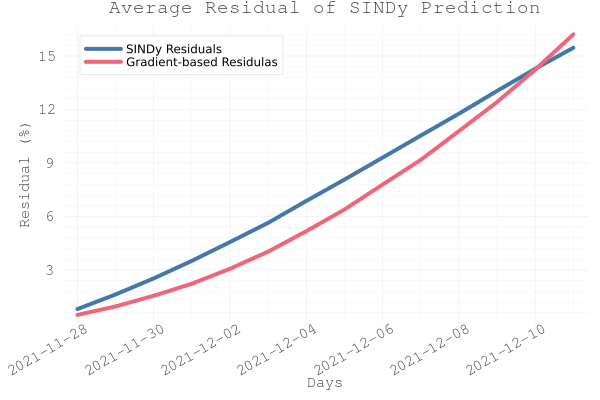

In [16]:
##### residual of the Local Coefficient Adjustment #####
rtemp1=mean(reduce(hcat,residuals1), dims=2)[2:end]./mean(reduce(hcat,real_cases))*100
plot!(mean(reduce(hcat,residuals1), dims=2)[2:end]./mean(reduce(hcat,real_cases))*100, label="Gradient-based Residulas", lw=4)


In [17]:
################################ calculating the average residual of the Time-dependent Coefficient Adjustment ######################################
#################### Making the Data #######################################
theme(:bright)#:ggplot2)

start_training=350
finish_training=680

residuals2=[]
for i=50:2:140
    split_start=500+i
    split_finish=520+i
    begin
      
        raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
        data=Matrix(raw_data[:,[2, 3]])'
      
        
        s=size(data)[2]
        for i in 1:s
            data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
        end
        ############# Beta distribution
      

        function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
            d=Beta(α, β)
            max=pdf(d, mode(d))
            step=1/(n+2-1)
            steps=collect(0.0:step: 1.0)
            coefs=zeros(length(steps))
            for i in eachindex(coefs)
                coefs[i]=pdf(d,steps[i])/max
            end
            return steps[2:end-1], coefs[2:end-1]
        end

        n=21  #### number of days that infection rate of each patient changes
        vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

    
        ###############################  factors should be  used ######################

        infectiveness=zeros(size(data)[2],1);
        infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
    
    
        for i in eachindex(infectiveness)
            infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
        end

    
        data1=copy(data)
        data1[2,:]=infectiveness
        Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
        Min=0
        for i in 1:size(data1)[1]
            for j in 1:size(data1)[2]
                data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
            end
        end 
               

        data2=data1[:,start_training:split_start]
        data3=data1[:,split_finish:finish_training]

        X1=copy(data2)
        X2=copy(data3)

    end

    ############################# Making control signal ########################
    begin
        v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
        v_data=Matrix{Float64}(v_raw_data[:,3:5])'

    
        ####  weekly averaging
        avg_days=7
        s=size(v_data)
        weekly=Matrix{Float64}(undef,s[1], s[2])
        for i in 1:size(v_data)[1]
            weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
        end
        
    
        ############# beta distribution  

        n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
        vvals, vcofs=factors(3,4,n) #### α=4 and β=4, we can change the curve shape by changing α and β
        


        ###############################  factors should be reversed and used ######################
        dose1=zeros(size(v_data)[2],1);
        dose2=zeros(size(v_data)[2],1);
        dose3=zeros(size(v_data)[2],1);

        vcofs1=reverse(reverse(vcofs))
        for i in 1:lastindex(dose1)
            for j in 1:min(n,i)-1
                dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
                dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
                dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
            end 
        end

        dose11=zeros(size(raw_data)[1],1);
        dose21=zeros(size(raw_data)[1],1);
        dose31=zeros(size(raw_data)[1],1);

        difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
        
        for i in difference+1:lastindex(dose11)
            dose11[i]=dose1[i-difference]
            dose21[i]=dose2[i-difference]
            dose31[i]=dose3[i-difference]
        end

        
        antibody=dose11.+dose21.+ dose31

        Max_antibody=maximum(antibody)
        Min=0
        for i in 1:size(antibody)[1]       
            antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
        end

        control=vcat(antibody') ### used in prediction
        control1=vcat(antibody[start_training:split_start]')
        control2=vcat(antibody[split_finish:finish_training]')


    end

    ######################## definition and solving of the problem ##################
    begin
        tick=100_000
       
        t1=collect(0.0:1/tick:(split_start-start_training)/tick);
        itp_method=InterpolationMethod(LinearInterpolation)
       
        t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);
       
        
        final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
        sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

        @variables u[1:2] c[1:1]
        u = collect(u)
        c = collect(c)

        if start_training==1
            h = Num[polynomial_basis([u; c], 1);]       
        else
            h = Num[polynomial_basis([u; c], 2);]       
        end

        basis = Basis(h, u, controls=c)


        ### choosing STLSQ as an optimizer
        ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
        opt = STLSQ(exp10.(-1:0.01:+5))

        options = DataDrivenCommonOptions(maxiters = 10_000,
                                    normalize = DataNormalization(ZScoreTransform),
                                    selector = aic, digits = 3)

        ddsol = solve(sir_problem, basis, opt, options=options)
        
    
    end

    ################## recovering the dynamic +window ########################
    window=6
    begin
        ##### range of prediction ####
        newdays=window
        start=split_start+newdays
        finish=split_finish
        
        
        res=ddsol
        sys = get_basis(res)
        

        # Optimal parameters
        p_opt = get_parameter_values(sys)
       
        
        z0=data1[:,start]
        

        ztspan=(start/tick,finish/tick)

        

        u=control
        tsteps = range(0.0, 706/tick, length = 707)
        A=LinearInterpolation(u,tsteps);


        function get_dose1(t)
            return A(t)[1]
        end


        function get_total_antibody(t)
            down=control[1, Int(round(t*tick+1, RoundDown))]
            up=control[1, Int(round(t*tick+1, RoundUp))]
            down_co=t*tick-round(t*tick,RoundDown)
            up_co=1-down_co
            control_in_t=down_co*down+up_co*up
            return control_in_t


        end

        # Generate a closure on the system 
        f_recovered = let doese_1 = get_dose1
        (x, p, t) -> sys(x, p, t, [doese_1.(t)])
        end
        f_recovered1 = let doese_1 = get_total_antibody
            (x, p, t) -> sys(x, p.+p_opt, t, [doese_1.(t)])
        end
    end

    ############################################ Optimisation with TV and for loop #######################################
    using Optim


    p1=get_parameter_values(sys);
    true_params = p1
    p=zeros(size(p1));
    all_prms=[]

    prms=[];
    [push!(prms, p1) for _ in 1:10]
    window=6;
    for step in 1:finish_training-start_training-window-1 #-180:20#
        new_data=data1[:,start_training+step:start_training+window+step]

        u0=new_data[:,1]
        tspan=((start_training+step)/tick, (start_training+window+step)/tick)
        t=collect((start_training+step)/tick:1/tick:(start_training+window+step)/tick)


        # Define the objective function for optimization
        function objective_function(params, data, alpha)
            y_observed = data
            prob = ODEProblem(f_recovered, u0, tspan, params)
            sol = solve(prob, saveat=1/tick)
            y_predicted = sol(t)
            error = y_observed .- y_predicted
            tmp_prms=copy(prms)
            push!(tmp_prms, params)
            tmp_prms=reduce(hcat, tmp_prms)
            tv_penalty=0
            for k in 1:length(params)
                tv_penalty+=sum(diff(tmp_prms[k,:]))
            end

            return sum(error.^2) + alpha * tv_penalty  # alpha is the regularization strength
        end
        

        
        true_params = p1
        data =new_data

        # Initial guess for ODE parameters
        initial_guess = p1 

        # Regularization strength
        alpha =sum(abs.(p_opt))exp10(-30)

        # Set other optimization parameters
        options = Optim.Options(iterations=100)
        
        result = Optim.optimize(params -> objective_function(params, data, alpha), initial_guess, LBFGS(), options)

        # Extract the optimized parameters
        optimized_params = Optim.minimizer(result)
        push!(all_prms, optimized_params)
        p1=optimized_params
        push!(prms, optimized_params)
        popfirst!(prms)

    end
    finial_prms=reduce(hcat, all_prms)

    #################### stochastic #########################
    p_opt3=finial_prms[:,split_start-start_training+1]
    begin
        theme(:bright)
        raw_data_end=CSV.File("Thuringen_SIRD_raw_2.csv") |> DataFrame
        data_end=Matrix(raw_data_end[:,[2, 3]])'
        t_step=1/tick
        beta=1
        
        g(u,p,t)=beta*u   #### stochastic function and its parameters

        ################## StatsPlots ################
        y1 = fill(NaN, finish-start+1, 10);
        y2 = fill(NaN, finish-start+1, 10);
        
        for i  in 1:10
            prediction_prob = SDEProblem(f_recovered, g, z0, ztspan, p_opt3)
            prediction = solve(prediction_prob, EM(), dt=t_step)
            M=Matrix(prediction)
        
        
            y1[:,i]=max.(M[1,:].-(z0[1]-data1[1,start]),0)
        
            y2[:,i]=M[2,:]
        
        end
        
    end
    push!(residuals2, (abs.(mean(y1,dims=2).-data1[1,start:finish]) ))
end

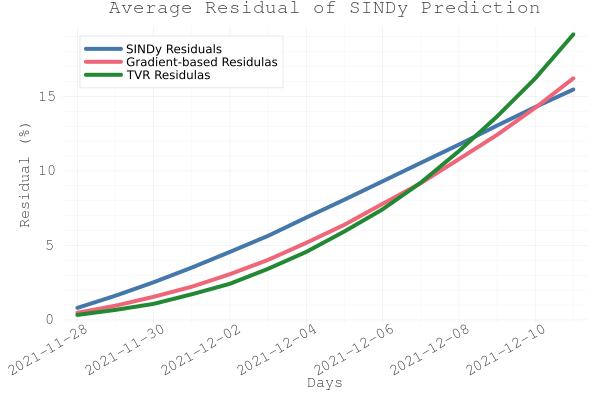

In [18]:
##### residual of the Time-dependent Coefficient Adjustment ####
rtemp2=mean(reduce(hcat,residuals2), dims=2)[2:end]./mean(reduce(hcat,real_cases))*100
plot!(mean(reduce(hcat,residuals2), dims=2)[2:end]./mean(reduce(hcat,real_cases))*100, label="TVR Residulas", lw=4)


In [19]:
################################ calculating the average residual of the Neural Augmented ODE adjustment ######################################
#################### Making the Data #######################################
theme(:bright)#:ggplot2)
#Random.seed!(598)

start_training=350
finish_training=680

residuals3=[]
for i=50:2:140
    split_start=500+i
    split_finish=520+i
    begin
      
        raw_data=CSV.File("Thuringen_SIRD_2.csv") |> DataFrame
        data=Matrix(raw_data[:,[2, 3]])'
      
        
        s=size(data)[2]
        for i in 1:s
            data[1,i]=mean(data[1,max(1,i-4):min(s,i)])
        end
        ############# Beta distribution
      
        function factors(α, β, n) ## Beta distribution, coefficients for n days needed (Infected)
            d=Beta(α, β)
            max=pdf(d, mode(d))
            step=1/(n+2-1)
            steps=collect(0.0:step: 1.0)
            coefs=zeros(length(steps))
            for i in eachindex(coefs)
                coefs[i]=pdf(d,steps[i])/max
            end
            return steps[2:end-1], coefs[2:end-1]
        end

        n=21  #### number of days that infection rate of each patient changes
        vals, cofs=factors(2.5,4.5,n) #### α=1.5 and β=2.5, we can change the curve shape by changing α and β

      
        ###############################  factors should be  used ######################

        infectiveness=zeros(size(data)[2],1);
        infectiveness=DSP.conv(cofs, data[1,:])[1:length(infectiveness)]
    
        #smoothing the infectiveness
        for i in eachindex(infectiveness)
            infectiveness[i]=mean(infectiveness[max(i-4,1):min(end, i)])
        end

    
        data1=copy(data)
        data1[2,:]=infectiveness
        Max_data1=[maximum(data1[i,1:end]) for i in 1:size(data1)[1]]
        Min=0
        for i in 1:size(data1)[1]
            for j in 1:size(data1)[2]
                data1[i,j]=(data1[i,j]-Min)/(Max_data1[i]-Min)
            end
        end 
        
       

        
        data2=data1[:,start_training:split_start]
        data3=data1[:,split_finish:finish_training]
        
        X1=copy(data2)
        X2=copy(data3)

    end

    ############################# Making control signal ########################
    begin
        v_raw_data=CSV.File("Thuringen_daily_vaccination.csv") |> DataFrame
        v_data=Matrix{Float64}(v_raw_data[:,3:5])'


    
        ####  weekly averaging
        avg_days=7
        s=size(v_data)
        weekly=Matrix{Float64}(undef,s[1], s[2])
        for i in 1:size(v_data)[1]
            weekly[i,:]=[mean(v_data[i, max(j-avg_days,1):j]) for j in 1:s[2]]'
        end

    
        ############# beta distribution  

        n=35 ## number of days needed to reach the peak of antibody and then goes down after vaccination
        vvals, vcofs=factors(3,4,n) #### α=4 and β=4, we can change the curve shape by changing α and β



        ###############################  factors should be reversed and used ######################
        dose1=zeros(size(v_data)[2],1);
        dose2=zeros(size(v_data)[2],1);
        dose3=zeros(size(v_data)[2],1);

        vcofs1=reverse(reverse(vcofs))
        for i in 1:lastindex(dose1)
            for j in 1:min(n,i)-1
                dose1[i]=dose1[i] + weekly[1, i-j] * vcofs1[j]
                dose2[i]=dose2[i] + weekly[2, i-j] * vcofs1[j]
                dose3[i]=dose3[i] + weekly[3, i-j] * vcofs1[j]
            end 
        end

        dose11=zeros(size(raw_data)[1],1);
        dose21=zeros(size(raw_data)[1],1);
        dose31=zeros(size(raw_data)[1],1);

        difference=Dates.value(v_raw_data[1,1]-raw_data[1,1])
        
        for i in difference+1:lastindex(dose11)
            dose11[i]=dose1[i-difference]
            dose21[i]=dose2[i-difference]
            dose31[i]=dose3[i-difference]
        end


        antibody=dose11.+dose21.+ dose31

        Max_antibody=maximum(antibody)
        Min=0
        for i in 1:size(antibody)[1]       
            antibody[i]=(antibody[i]-Min)/(Max_antibody-Min)
        end

        control=vcat(antibody') ### used in prediction
        control1=vcat(antibody[start_training:split_start]')
        control2=vcat(antibody[split_finish:finish_training]')

    end

    ######################## definition and solving of the problem ##################
    begin
        tick=100_000

        t1=collect(0.0:1/tick:(split_start-start_training)/tick);
        itp_method=InterpolationMethod(LinearInterpolation)



        t2=collect(0.0:1/tick:(finish_training-split_finish)/tick);

        
        final_data=(prob1=(X=X1, t=t1, itp_method, U=control1), prob2=(X=X2, t=t2,  itp_method, U=control2))
        sir_problem=ContinuousDataset(final_data)#(sir_problem1, sir_problem2

        @variables u[1:2] c[1:1]
        u = collect(u)
        c = collect(c)

        if start_training==1
            h = Num[polynomial_basis([u; c], 1);]            
        else
            h = Num[polynomial_basis([u; c], 2);]            
        end

        basis = Basis(h, u, controls=c)


        ### choosing STLSQ as an optimizer
        ### STLSQ is a sparsifying algorithm that cause the solve function to call its "Sindy" method ###
        opt = STLSQ(exp10.(-1:0.01:+5))


        
        options = DataDrivenCommonOptions(maxiters = 10_000,
                                    normalize = DataNormalization(ZScoreTransform),
                                    selector = aic, digits = 3)

        ddsol = solve(sir_problem, basis, opt, options=options)
        
    
    end

    ################## recovering the dynamic +window ########################
    window=6
    begin
        ##### range of prediction ####
        newdays=window
        start=split_start
        finish=split_finish
        
        
        res=ddsol
        sys = get_basis(res)
        

        # Optimal parameters
        p_opt = get_parameter_values(sys)
       
        
        z0=data1[:,start]
        

        ztspan=(start/tick,finish/tick)

        

        u=control
        tsteps = range(0.0, 706/tick, length = 707)
        A=LinearInterpolation(u,tsteps);



        function get_dose1(t)
            return A(t)[1]
        end

        
        function get_total_antibody(t)
            down=control[1, Int(round(t*tick+1, RoundDown))]
            up=control[1, Int(round(t*tick+1, RoundUp))]
            down_co=t*tick-round(t*tick,RoundDown)
            up_co=1-down_co
            control_in_t=down_co*down+up_co*up
            return control_in_t

        
        end

        # Generate a closure on the system 
        f_recovered = let doese_1 = get_dose1
        (x, p, t) -> sys(x, p, t, [doese_1.(t)])       
        end
    end

    ############################# Universal Differential Equations ###############
    using Lux, SciMLSensitivity
    using Optimization, OptimizationOptimisers, OptimizationOptimJL
    
    rbf(x) = exp.(-(x .^ 2))

    # Multilayer FeedForward
    U = Lux.Chain(Lux.Dense(2, 5, rbf), Lux.Dense(5, 5, rbf), Lux.Dense(5, 5, rbf),
                Lux.Dense(5, 2))
    
    rng = StableRNG(12100)
    p, st = Lux.setup(rng, U)
    
    function ude_dynamics!(du, u, p, t, p_true)
    
        û = U(u, p, st)[1] 
        tmp=f_recovered(u, p_true, t)
       
        du[1] = tmp[1] + û[1];
        du[2] = tmp[2] + û[2];
        
    end

    # Closure with the known parameter
    nn_dynamics!(du, u, p, t) = ude_dynamics!(du, u, p, t, p_opt)
    # Define the problem
    prob_nn = ODEProblem(nn_dynamics!, z0, ztspan, p)
    
    start=split_start
    finish=split_start+6#min(split_finish+0, 680)#680#
    t=collect(start/tick:1/tick:finish/tick)
    z0=data1[:,start]

    using ComponentArrays

    function pred(θ, X = z0, T = t)
        _prob = remake(prob_nn, u0 = X, tspan = (T[1], T[end]), p = θ)
        Array(solve(_prob, Tsit5(), saveat = T,# dt=0.01/tick,
                    abstol = 1e-6, reltol = 1e-6))
    end
    function loss(θ)
        X̂ = pred(θ)
    
        mean(abs2, data1[:,start:finish] .- X̂)
    end
    losses = Float64[]

    callback = function (p, l)
    
        push!(losses, l)
        if length(losses) % 1 == 1000
            println("Current loss after $(length(losses)) iterations: $(losses[end])")
        end
        return false
    end
    adtype = Optimization.AutoForwardDiff()
    
    optf = Optimization.OptimizationFunction((x, p) -> loss(x), adtype)
    optprob = Optimization.OptimizationProblem(optf, ComponentVector{Float64}(p))

    itr=2000
    using SciMLSensitivity
    using Optimization, OptimizationOptimisers, OptimizationOptimJL
    res1 = Optimization.solve(optprob, ADAM(0.001), callback = callback, maxiters = itr)
    
    println("Training loss after $(length(losses)) iterations: $(losses[end])")

    optprob2 = Optimization.OptimizationProblem(optf, res1.u)
    res2 = Optimization.solve(optprob2, Optim.LBFGS(), callback = callback, maxiters = 1000)
    println("Final training loss after $(length(losses)) iterations: $(losses[end])")

    p_trained=res2.u


    days_after=6
    start=split_start+days_after
    finish=split_finish
    t1=collect((start)/tick:1/tick:(finish)/tick)
    x1=data1[:, start]
    y1=pred(p_trained, x1, t1)[1,:]
    y1=max.(y1,0)

    push!(residuals3, (abs.(y1.-data1[1,start:finish]) ))#./(data1[1,start:finish]).*100))
end

Training loss after 2001 iterations: 8.333406695088435e-6
Final training loss after 2003 iterations: 8.045423478966504e-8
Training loss after 2001 iterations: 1.2883314866579214e-5
Final training loss after 2003 iterations: 4.854480088608254e-8
Training loss after 2001 iterations: 1.622574918024093e-5
Final training loss after 2003 iterations: 5.9344764131953443e-8
Training loss after 2001 iterations: 1.840915715852423e-5
Final training loss after 2004 iterations: 9.773847250673104e-9
Training loss after 2001 iterations: 2.442543377451957e-5
Final training loss after 2004 iterations: 2.544364221450974e-7
Training loss after 2001 iterations: 3.25741482235877e-5
Final training loss after 2004 iterations: 1.8823257305804492e-7
Training loss after 2001 iterations: 4.013672696364941e-5
Final training loss after 2005 iterations: 2.0151114320880148e-7
Training loss after 2001 iterations: 2.2410484398592842e-5
Final training loss after 2004 iterations: 1.2465712224031213e-8
Training loss after

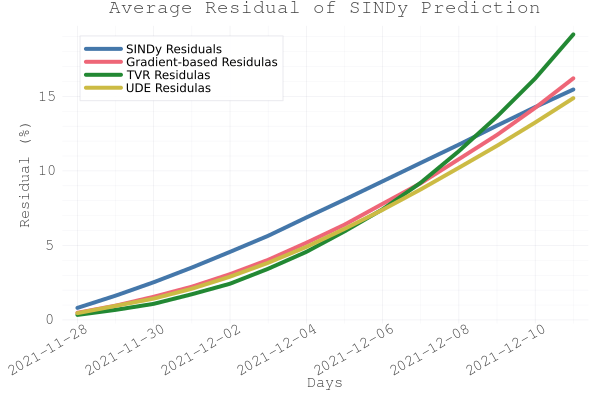

In [20]:
##### residual of the Neural Augmented ODE adjustment #####
rtemp3=mean(reduce(hcat,residuals3), dims=2)[2:end]./mean(reduce(hcat,real_cases))*100
plot!(mean(reduce(hcat,residuals3), dims=2)[2:end]./mean(reduce(hcat,real_cases))*100, label="UDE Residulas", lw=4)


In [42]:
###### Figure 11  #########
groupedbar([rtemp';rtemp1';rtemp2';rtemp3']', label=["Global Coefficients" "Local Coefficient Adjustment" "Time-dependent Coefficient Adjustment" "Neural-augmented ODE Adjustment"],
            bar_width = 0.65, lw = 0,  bar_position = :dodge, framestyle = :box, xticks = (1:1:14), xminorticks = 1,
            size=(750,400), left_margin = 5Plots.mm, bottom_margin = 5Plots.mm, right_margin = 5Plots.mm, color=  ["#377eb8" "#ff7f00" "#4daf4a" "#e41a1c"],
            titlefont=font(10,"Arial"), guidefont = font(8,"Arial"),  dpi = 300,
            ytickfont=font(8, "Arial"), xtickfont=font(8,"Arial"), title="Evaluating Model Fit: Mean Absolute Residuals",
            xlabel="Day", ylabel="Residuals(percentage)")

yaxis!("Residuals(Percentage)", (0:10:100, ["$(x)%" for x in 0:10:100]))
ylims!(0,20)
savefig("Fig11.pdf")

"c:\\Users\\babazadehmorteza\\Desktop\\CovidModelling\\FirstModelSindy\\Fig11.pdf"

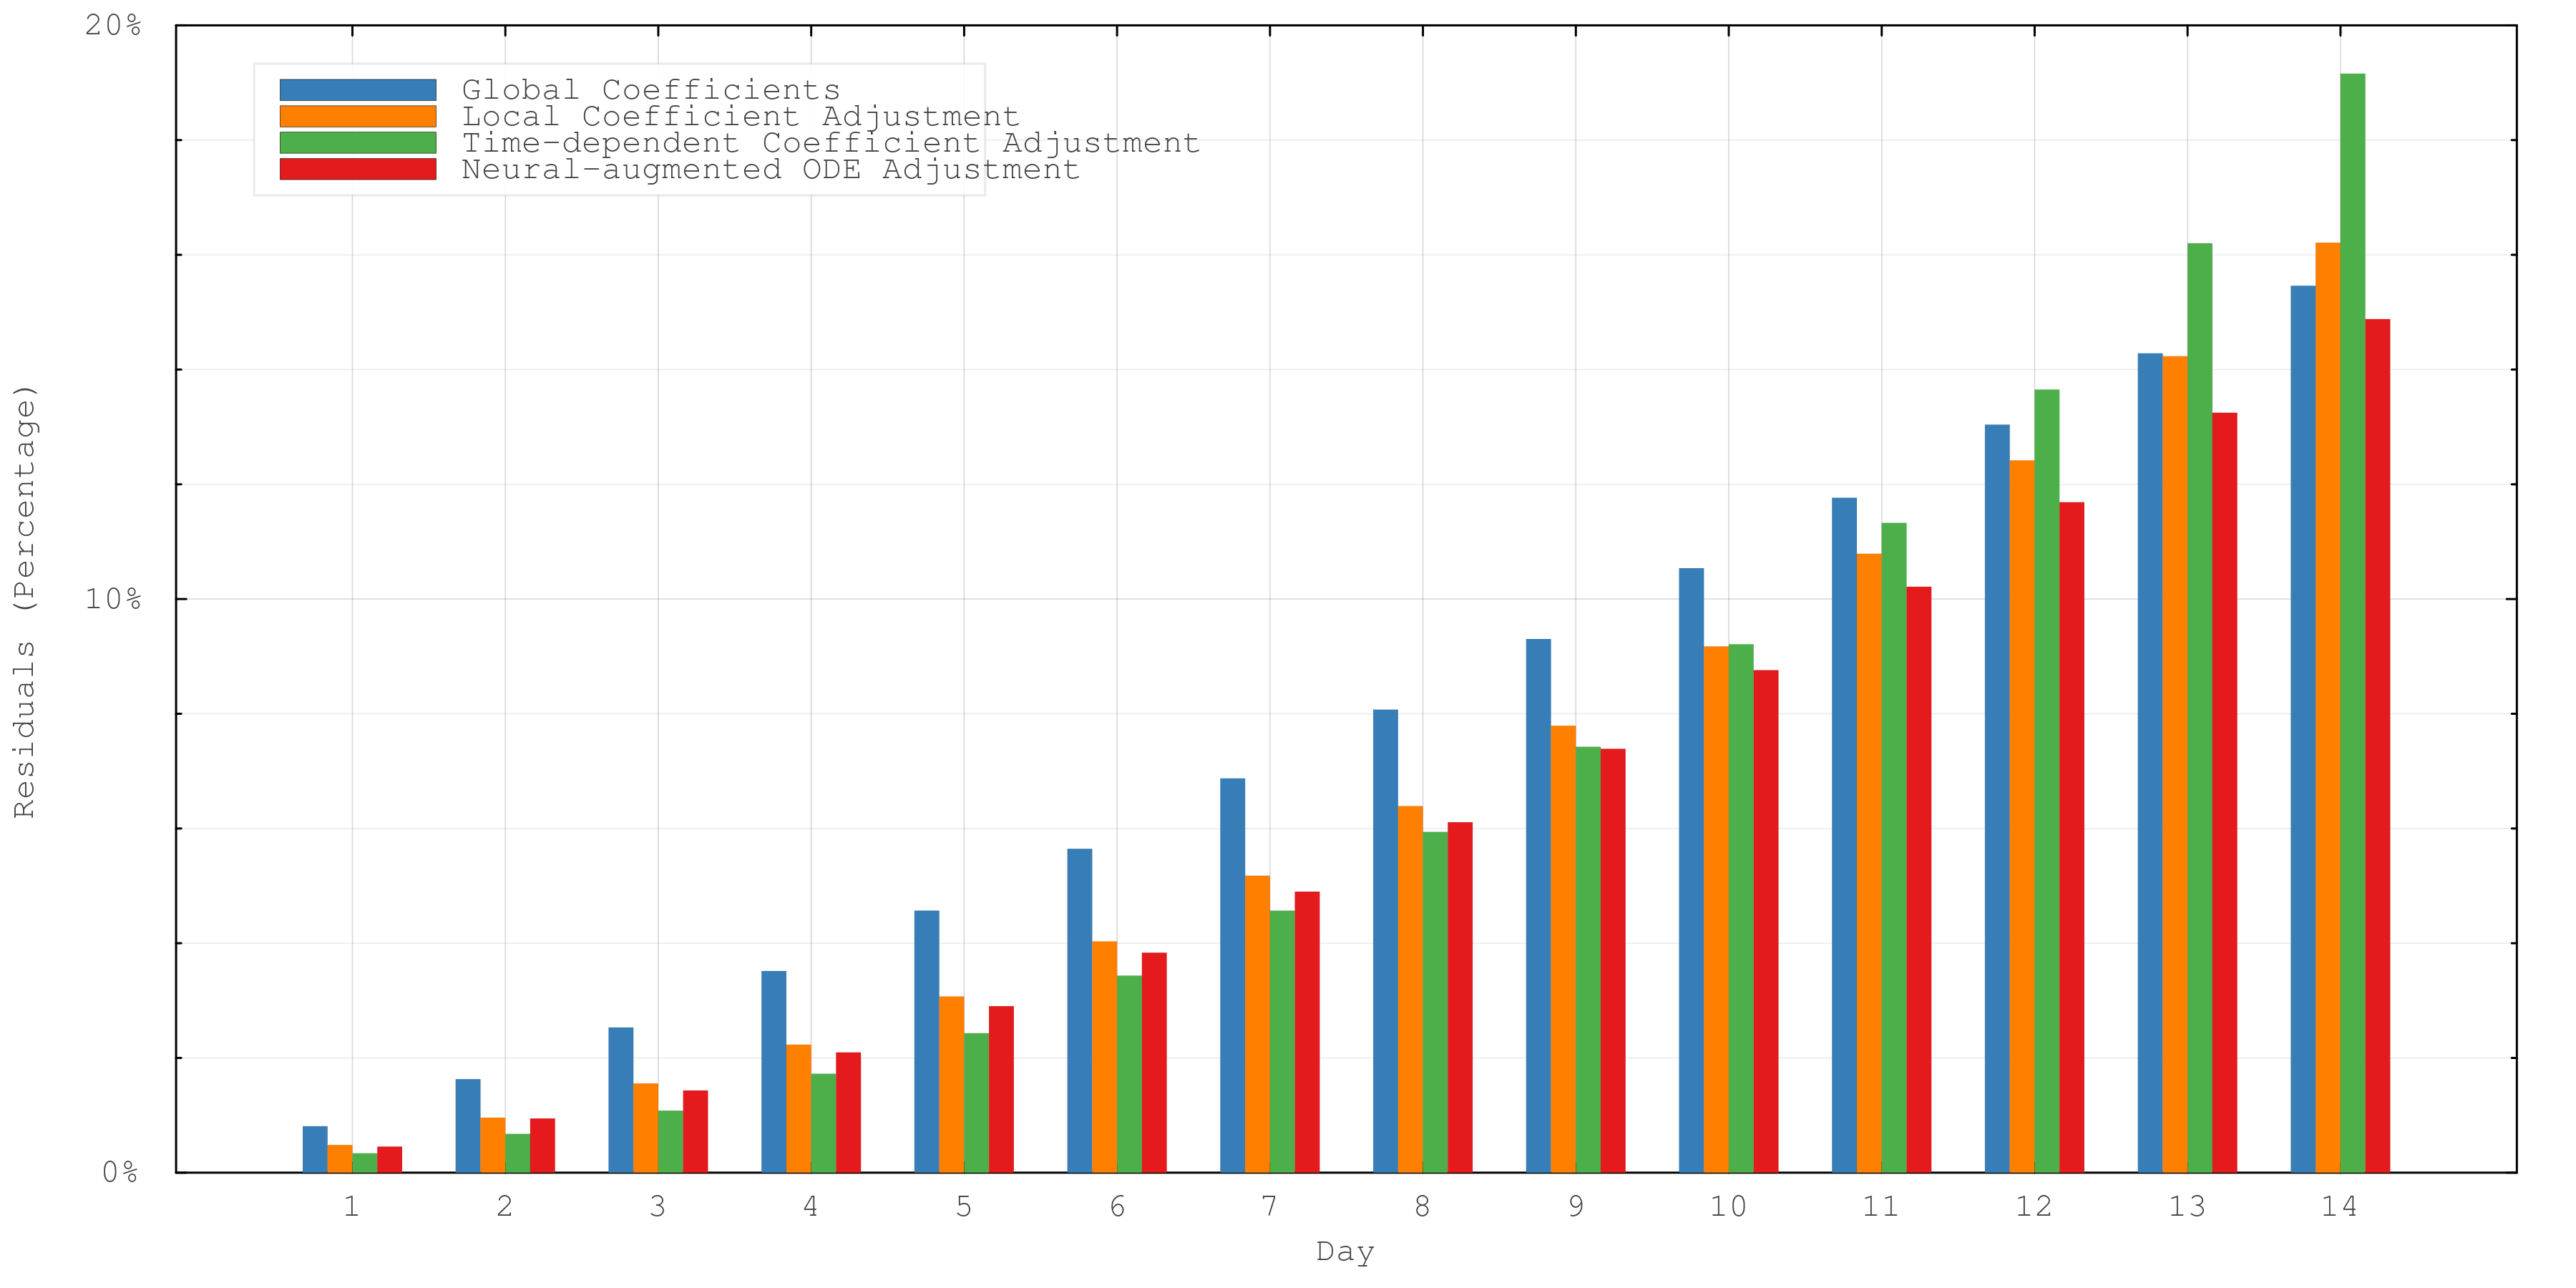

In [36]:
groupedbar([rtemp'; rtemp1'; rtemp2'; rtemp3']',
    label=["Global Coefficients" "Local Coefficient Adjustment" "Time-dependent Coefficient Adjustment" "Neural-augmented ODE Adjustment"],
    bar_width=0.65, lw=0, bar_position=:dodge, framestyle=:box,
    xticks=(1:1:14), xminorticks=1,
    size=(1200, 600),
    left_margin=5Plots.mm, bottom_margin=5Plots.mm, right_margin=5Plots.mm,
    color=["#377eb8" "#ff7f00" "#4daf4a" "#e41a1c"],
    guidefont=font(8, "Arial"),
    ytickfont=font(8, "Arial"),
    xtickfont=font(8, "Arial"),
    legendfont=font(8, "Arial"),
    dpi=300,
    xlabel="Day",
    ylabel="Residuals (Percentage)")

yaxis!("Residuals (Percentage)", (0:10:100, ["$(x)%" for x in 0:10:100]))
ylims!(0, 20)

#savefig("Fig11.png")

In [ ]:
######### Table 5 #########################
using Statistics
using Random

Random.seed!(42)

# Block bootstrap configuration
n_bootstrap = 1000
block_size = 7

# All four models: global, local, time-dependent, neural-augmented
all_residuals = [residuals, residuals1, residuals2, residuals3]
model_names = ["Global coefficients", "Local coefficient adj.", 
               "Time-dependent coeff. adj.", "Neural-augmented ODE adj."]

# Store results for table output
results = Dict()

for (m, (res_data, mname)) in enumerate(zip(all_residuals, model_names))
    
    res_matrix = reduce(hcat, res_data)
    cases_matrix = reduce(hcat, real_cases)
    
    n_folds = size(res_matrix, 2)
    n_blocks = ceil(Int, n_folds / block_size)
    
    for ii in [3, 7, 10, 14]
        
        # --- RMSE and MAE: computed per fold then averaged ---
        rmse_vals = Float64[]
        mae_vals  = Float64[]
        for k in 1:n_folds
            res_k = res_matrix[1:ii, k]
            push!(rmse_vals, sqrt(mean(res_k .^ 2)) * Max_data1[1])
            push!(mae_vals,  mean(abs.(res_k)) * Max_data1[1])
        end
        rmse_orig = mean(rmse_vals)
        mae_orig  = mean(mae_vals)
        
        # --- R²: computed on the mean forecast trajectory ---
        res_mean = mean(res_matrix[1:ii, :], dims=2)[:]
        cases_mean = mean(cases_matrix[1:ii, :], dims=2)[:]
        mean_cases = mean(cases_mean)
        ss_tot = sum((cases_mean .- mean_cases) .^ 2)
        ss_res = sum(res_mean .^ 2)
        r2_orig = 1 - (ss_res / ss_tot)
        
        # --- Block bootstrap for 95% confidence intervals ---
        boot_rmse = Float64[]
        boot_mae  = Float64[]
        boot_r2   = Float64[]
        
        for _ in 1:n_bootstrap
            starts = rand(1:(n_folds - block_size + 1), n_blocks)
            idx = Int[]
            for s in starts
                append!(idx, s:(s + block_size - 1))
            end
            idx = idx[1:n_folds]
            
            push!(boot_rmse, mean(rmse_vals[idx]))
            push!(boot_mae,  mean(mae_vals[idx]))
            
            res_boot = mean(res_matrix[1:ii, idx], dims=2)[:]
            cases_boot = mean(cases_matrix[1:ii, idx], dims=2)[:]
            mc = mean(cases_boot)
            st = sum((cases_boot .- mc) .^ 2)
            sr = sum(res_boot .^ 2)
            if st > 0
                push!(boot_r2, 1 - (sr / st))
            end
        end
        
        results[(m, ii)] = (
            rmse = round(rmse_orig, digits=2),
            rmse_ci = round.(quantile(boot_rmse, [0.025, 0.975]), digits=2),
            mae = round(mae_orig, digits=2),
            mae_ci = round.(quantile(boot_mae, [0.025, 0.975]), digits=2),
            r2 = round(r2_orig, digits=2),
            r2_ci = round.(quantile(boot_r2, [0.025, 0.975]), digits=2)
        )
    end
end

# --- Print formatted table ---
println("=" ^ 130)
println("Table 5. Comparative performance metrics with 95% bootstrap confidence intervals")
println("=" ^ 130)

header = rpad("Day", 5)
for mname in model_names
    header *= " | " * rpad(mname, 28)
end
println(header)
println("-" ^ 130)

for ii in [3, 7, 10, 14]
    # R² row
    line_r2 = rpad("$(ii)", 5)
    for m in 1:4
        r = results[(m, ii)]
        line_r2 *= " | " * rpad("R²=$(r.r2) $(r.r2_ci)", 28)
    end
    
    # RMSE row
    line_rmse = rpad("", 5)
    for m in 1:4
        r = results[(m, ii)]
        line_rmse *= " | " * rpad("RMSE=$(r.rmse) $(r.rmse_ci)", 28)
    end
    
    # MAE row
    line_mae = rpad("", 5)
    for m in 1:4
        r = results[(m, ii)]
        line_mae *= " | " * rpad("MAE=$(r.mae) $(r.mae_ci)", 28)
    end
    
    println(line_r2)
    println(line_rmse)
    println(line_mae)
    println("-" ^ 130)
end

Table 5. Comparative performance metrics with 95% bootstrap confidence intervals
Day   | Global coefficients          | Local coefficient adj.       | Time-dependent coeff. adj.   | Neural-augmented ODE adj.   
----------------------------------------------------------------------------------------------------------------------------------
3     | R²=0.75 [0.59, 0.89]         | R²=0.91 [0.86, 0.97]         | R²=0.96 [0.92, 0.98]         | R²=0.92 [0.87, 0.96]        
      | RMSE=15.68 [8.92, 22.21]     | RMSE=9.39 [4.46, 14.65]      | RMSE=6.73 [4.13, 8.93]       | RMSE=9.14 [4.81, 13.61]     
      | MAE=11.96 [6.68, 17.01]      | MAE=7.06 [3.37, 10.96]       | MAE=4.97 [3.04, 6.59]        | MAE=6.86 [3.58, 10.23]      
----------------------------------------------------------------------------------------------------------------------------------
7     | R²=0.58 [0.28, 0.82]         | R²=0.81 [0.59, 0.95]         | R²=0.87 [0.83, 0.94]         | R²=0.83 [0.72, 0.92]        
      |